![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 03 | Hypotheses and Visualisation

*Project 1 — SQL: From Data to Insight*

**Team:**
**Dataset:**

---

**This notebook is your report.** It is read on its own, by someone who has not seen notebooks 01 and 02, so it needs the prose as much as the code: the question, the evidence, and what you concluded. Keep the messy exploration in the other two.

> **Done when:** someone who has never met your project can read this top to bottom and understand what you asked, what the data said, and how confident they should be.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [5]:
import sqlite3

conn = sqlite3.connect("../data/project.db")

print("Connected to project.db")

Connected to project.db


In [11]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

---
## 1. The question

What you set out to find out, and why it matters. Your research questions from notebook 01, with the hypothesis for each.

## 1. The question

For this project I am looking at the data from the point of view of a potential Airbnb investor in Barcelona.

The aim is not to identify a guaranteed investment opportunity, but to use the available data to narrow down which areas may be worth investigating further.

### Research questions

**1. Which Barcelona districts offer the strongest nightly pricing potential for comparable Airbnb listings?**

I expect prices to vary significantly by district, but I also want to check whether those differences remain when I compare similar room types and guest capacity.

**2. Which Barcelona districts show the strongest recent guest activity relative to the amount of Airbnb supply?**

A district with a high number of reviews may simply have more listings, so I will compare recent review activity with the amount of supply in each area.

**3. Which Barcelona districts have the highest concentration of supply controlled by hosts with multiple listings?**

This gives some indication of the competitive landscape and whether a potential investor would be entering a market dominated by individual hosts or larger portfolios.

### Overall question

**Where in Barcelona should a potential Airbnb investor investigate further, based on pricing potential, evidence of guest activity and the competitive landscape?**

---
## 2. The data

Where it came from, what one row is, and what your database looks like. Show the ERD.

## 2. The data

The project uses the Barcelona Inside Airbnb dataset. The original data comes as two files: one row per listing and one row per review. The listings file contains 15,293 properties, while the original reviews file contains just over one million review records. 

For the database, I split the data into four related tables.

### `locations`

This contains one row for each neighbourhood, together with the Barcelona district it belongs to.

The main fields are:

- `location_id` — the primary key
- `neighbourhood_name`
- `district_name`

### `hosts`

This contains one row for each host rather than repeating the same host information across every listing.

The main fields are:

- `host_id` — the primary key
- `host_name`
- `host_is_superhost`

### `listings`

This is the main table and contains one row for each Airbnb listing.

It includes the fields needed for the analysis, such as:

- `listing_id` — the primary key
- `host_id` — links the listing to the host
- `location_id` — links the listing to its neighbourhood and district
- `room_type`
- `accommodates`
- `price`
- `minimum_nights`
- `number_of_reviews`
- estimated occupancy and revenue indicators

### `reviews`

This contains the individual review records used to measure guest activity over time.

The main fields are:

- `review_id` — the primary key
- `listing_id` — links each review back to the listing
- `review_date`

### How the tables connect

`listings` sits at the centre of the database.

Each listing links to one host through `host_id` and one location through `location_id`.

The reviews table then links back to listings through `listing_id`.

So the structure is:

`hosts` → `listings` ← `locations`

`reviews` → `listings`

This keeps repeated information out of the main listings table and means I can combine pricing, location, host and review activity using SQL joins.

The estimated occupancy and revenue fields are indicators rather than observed bookings or actual revenue, so I use them as supporting evidence rather than confirmed performance.

Data from Inside Airbnb, licensed under CC BY 4.0. 

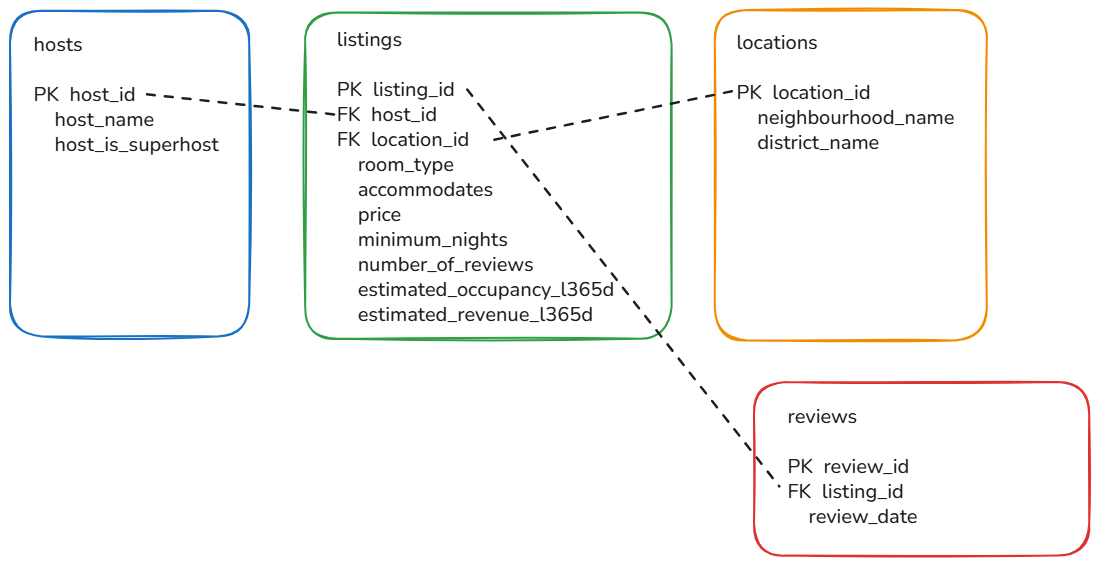

## 3. Analysis

I used SQL to answer the three research questions, with the calculations done in the database and the results brought into pandas for comparison and visualisation.

The analysis starts with pricing, then looks at recent guest activity, followed by the competitive landscape. The final query brings the main measures together at district level.

In [21]:
from pathlib import Path

sql_text = Path("../sql/queries.sql").read_text()



The SQL analysis is stored in `sql/queries.sql`. Rather than repeating the SQL code in this notebook, I load the completed queries from that file and use pandas to run them against the SQLite database.

The results are then used here to answer each research question and build the visualisations.

In [22]:
from pathlib import Path

sql_text = Path("../sql/queries.sql").read_text(encoding="utf-8")

queries = [
    query.strip()
    for query in sql_text.split(";")
    if query.strip()
]

print(f"{len(queries)} queries loaded")

7 queries loaded


### 3.1 Nightly pricing potential

The first question is whether some Barcelona districts support higher typical nightly prices than others.

I start with the median nightly price by district. I use the median rather than the average because a small number of very expensive properties could otherwise distort the result.

In [23]:
q1_result = pd.read_sql(queries[0], conn)
q1_result

,district_name,listings_with_price,median_nightly_price
0,Eixample,5194,229.00
1,Sant Martí,1235,206.50
2,Gràcia,1197,187.00
3,Sants-Montjuïc,1276,186.81
4,Les Corts,272,172.27
5,Sarrià-Sant Gervasi,779,149.34
6,Horta-Guinardó,290,118.48
7,Ciutat Vella,2788,115.44
8,Nou Barris,142,95.69
9,Sant Andreu,182,80.00


**Finding:** Eixample has the highest overall median nightly asking price at €229, followed by Sant Martí at €206.50. Gràcia and Sants-Montjuïc are also relatively high at around €187.

However, these figures do not yet account for differences in the type or size of listings available in each district. The next step is therefore to compare listings with the same room type and guest capacity to see whether the district price differences remain.

### Like-for-like price comparison

The overall district prices may be affected by the mix of properties available. To make the comparison fairer, I now compare listings with the same room type and guest capacity.

I only include groups with at least 20 listings so that very small groups do not have too much influence on the comparison.

In [24]:
q2_result = pd.read_sql(queries[1], conn)
q2_result

,district_name,room_type,accommodates,comparable_listings,median_nightly_price
0,Eixample,Entire home/apt,2,504,179.87
1,Sarrià-Sant Gervasi,Entire home/apt,2,91,159.00
2,Sant Martí,Entire home/apt,2,186,147.00
3,Sants-Montjuïc,Entire home/apt,2,188,145.94
4,Gràcia,Entire home/apt,2,195,138.24
...,...,...,...,...,...
77,Eixample,Private room,3,75,180.00
78,Ciutat Vella,Private room,3,63,142.00
79,Eixample,Private room,4,46,210.50
80,Ciutat Vella,Private room,4,35,154.79


In [25]:
q2_entire_2 = q2_result[
    (q2_result["room_type"] == "Entire home/apt") &
    (q2_result["accommodates"] == 2)
].sort_values("median_nightly_price", ascending=False)

q2_entire_2

,district_name,room_type,accommodates,comparable_listings,median_nightly_price
0,Eixample,Entire home/apt,2,504,179.87
1,Sarrià-Sant Gervasi,Entire home/apt,2,91,159.00
2,Sant Martí,Entire home/apt,2,186,147.00
3,Sants-Montjuïc,Entire home/apt,2,188,145.94
4,Gràcia,Entire home/apt,2,195,138.24
5,Les Corts,Entire home/apt,2,31,116.50
6,Sant Andreu,Entire home/apt,2,29,94.02
7,Horta-Guinardó,Entire home/apt,2,33,85.93
8,Ciutat Vella,Entire home/apt,2,757,84.85


**Finding:** Eixample remains the highest-priced district in this like-for-like comparison. For entire homes or apartments accommodating two guests, the median nightly asking price is €179.87, compared with €159.00 in Sarrià-Sant Gervasi and €147.00 in Sant Martí.

This suggests that Eixample's higher overall pricing is not only caused by having a different mix of property types. The district still commands a higher typical asking price when similar listings are compared.

### 3.2 Recent guest activity

Higher asking prices are more interesting if there is also evidence of guest activity.

I use reviews from the most recent 12 months as a proxy for recent guest activity. I compare review activity with the number of listings in each district so that larger districts do not automatically appear stronger simply because they have more Airbnb supply.

In [26]:
q3_result = pd.read_sql(queries[2], conn)
q3_result

,district_name,listings,recent_reviews,recent_reviews_per_listing,listings_with_recent_reviews,pct_listings_with_recent_reviews
0,Eixample,5835,93135,15.96,3866,66.26
1,Sants-Montjuïc,1448,22107,15.27,981,67.75
2,Sant Martí,1436,21865,15.23,949,66.09
3,Gràcia,1366,20752,15.19,904,66.18
4,Les Corts,327,4084,12.49,228,69.72
5,Horta-Guinardó,358,2980,8.32,208,58.10
6,Sarrià-Sant Gervasi,888,7080,7.97,447,50.34
7,Ciutat Vella,3247,24419,7.52,1899,58.48
8,Sant Andreu,225,1377,6.12,105,46.67
9,Nou Barris,163,450,2.76,48,29.45


In [27]:
q3_result = pd.read_sql(queries[2], conn)
q3_result

,district_name,listings,recent_reviews,recent_reviews_per_listing,listings_with_recent_reviews,pct_listings_with_recent_reviews
0,Eixample,5835,93135,15.96,3866,66.26
1,Sants-Montjuïc,1448,22107,15.27,981,67.75
2,Sant Martí,1436,21865,15.23,949,66.09
3,Gràcia,1366,20752,15.19,904,66.18
4,Les Corts,327,4084,12.49,228,69.72
5,Horta-Guinardó,358,2980,8.32,208,58.10
6,Sarrià-Sant Gervasi,888,7080,7.97,447,50.34
7,Ciutat Vella,3247,24419,7.52,1899,58.48
8,Sant Andreu,225,1377,6.12,105,46.67
9,Nou Barris,163,450,2.76,48,29.45


**Finding:** Eixample has the highest recent review activity relative to supply, with 15.96 reviews per listing over the most recent 12 months. Sants-Montjuïc, Sant Martí and Gràcia are very close behind at around 15 reviews per listing.

Ciutat Vella has a much larger supply of listings but only 7.52 recent reviews per listing, suggesting that its overall review volume is partly driven by the size of the market rather than stronger activity per property.

Les Corts has the highest proportion of listings with at least one recent review at 69.72%, showing relatively broad activity across its smaller supply.

Reviews are used here as a proxy for guest activity rather than a direct measure of bookings.

#### Supporting occupancy and revenue indicators

Inside Airbnb also provides estimated occupancy and revenue figures. These are estimates rather than observed bookings or actual revenue, so I use them only as supporting evidence alongside the review activity.

In [28]:
q4_result = pd.read_sql(queries[3], conn)
q4_result

,district_name,listings,avg_estimated_occupancy,avg_estimated_revenue,listings_with_revenue_estimate
0,Sants-Montjuïc,1448,98.5,21557.96,1276
1,Gràcia,1366,95.2,23869.85,1197
2,Eixample,5835,94.6,28530.62,5194
3,Sant Martí,1436,92.0,23455.47,1235
4,Les Corts,327,81.1,16236.47,272
5,Horta-Guinardó,358,78.4,15027.86,290
6,Ciutat Vella,3247,75.0,13688.80,2788
7,Sant Andreu,225,58.0,8935.07,182
8,Sarrià-Sant Gervasi,888,57.5,12690.22,779
9,Nou Barris,163,29.7,3570.86,142


**Finding:** The modelled occupancy and revenue indicators broadly support the pattern seen in the recent review data. Sants-Montjuïc has the highest estimated average occupancy at 98.5 days, while Eixample has the highest estimated average revenue at approximately €28,531.

Eixample, Sants-Montjuïc, Gràcia and Sant Martí all appear relatively strong across both recent review activity and the modelled indicators, although their order differs depending on the measure.

Sarrià-Sant Gervasi provides an interesting contrast: despite relatively high asking prices, its estimated occupancy is much lower at 57.5 days.

These figures are modelled estimates, so I use them as supporting evidence rather than treating them as confirmed bookings or revenue.

### 3.3 Multi-listing host concentration

The final research question looks at the competitive landscape.

I define a multi-listing host as a host with more than one Airbnb listing in Barcelona. I then compare districts based on how much of their Airbnb supply belongs to these hosts.

This helps show whether a district is made up mainly of individual hosts or whether a large share of listings is controlled by hosts with larger portfolios.

In [29]:
q5_result = pd.read_sql(queries[4], conn)
q5_result

,district_name,district_listings,distinct_hosts,listings_per_host,multi_listing_hosts,pct_hosts_with_multiple_listings,listings_from_multi_listing_hosts,pct_listings_from_multi_listing_hosts
0,Eixample,5835,1611,3.62,799,49.60,5023,86.08
1,Sarrià-Sant Gervasi,888,282,3.15,158,56.03,764,86.04
2,Les Corts,327,141,2.32,90,63.83,276,84.40
3,Ciutat Vella,3247,1255,2.59,587,46.77,2579,79.43
4,Gràcia,1366,604,2.26,315,52.15,1077,78.84
5,Sants-Montjuïc,1448,707,2.05,323,45.69,1064,73.48
6,Sant Martí,1436,710,2.02,300,42.25,1026,71.45
7,Sant Andreu,225,121,1.86,55,45.45,159,70.67
8,Nou Barris,163,85,1.92,29,34.12,107,65.64
9,Horta-Guinardó,358,245,1.46,117,47.76,230,64.25


**Finding:** Multi-listing hosts control a large share of Airbnb supply across Barcelona.

Eixample and Sarrià-Sant Gervasi have the highest concentration, with just over 86% of listings belonging to hosts with more than one Barcelona property. Les Corts is also high at 84.40%.

This suggests that some of the districts with the strongest pricing potential also have a more concentrated competitive landscape, with a large share of supply controlled by hosts operating multiple listings.

Horta-Guinardó has the lowest concentration in this comparison at 64.25%, although multi-listing hosts still control the majority of supply there.

In [30]:
q6_result = pd.read_sql(queries[5], conn)
q6_result

,host_id,host_name,total_listings,districts_present,entire_home_listings,avg_nightly_price
0,346367515,Ukio,588,7,588,146.05
1,1447144,Acomodis Apartments,448,6,448,1226.39
2,21726991,Silvia De Lourdes,359,10,358,151.91
3,32037490,Sweett,293,7,288,278.84
4,4459553,AB Apartment Barcelona,243,7,243,335.79
5,221480824,Badi Plus,243,7,35,61.73
6,299462,Stay Unique,140,8,140,343.95
7,36607755,Room Housing,136,5,0,38.48
8,265193861,BeBarceloner,125,7,120,211.03
9,158023606,Habitat Apartments,120,6,120,263.96


**Finding:** The concentration of supply among multi-listing hosts includes some very large portfolios rather than simply hosts with two or three properties.

The largest host in the dataset has 588 listings across seven Barcelona districts, while several other hosts control more than 200 listings. Some large hosts also operate across most of the city, with one portfolio represented in all ten districts.

The type of supply varies between these portfolios. Some are made up almost entirely of entire homes or apartments, while others contain mainly rooms. This shows that multi-listing hosts are not one uniform group, but large portfolios form a meaningful part of Barcelona's Airbnb competitive landscape.

### 3.4 Combined district view

The final query brings the main measures from the three research questions together at district level.

This lets me compare pricing potential, recent guest activity and the concentration of supply among multi-listing hosts in one table rather than looking at each measure separately.

I have not created an artificial investment score, because these measures describe different parts of the market and the trade-offs are more useful to see directly.

In [31]:
q7_result = pd.read_sql(queries[6], conn)
q7_result

,district_name,listings,median_nightly_price,recent_reviews_per_listing,distinct_hosts,pct_listings_from_multi_listing_hosts
0,Eixample,5835,229.00,15.96,1611,86.08
1,Sant Martí,1436,206.50,15.23,710,71.45
2,Gràcia,1366,187.00,15.19,604,78.84
3,Sants-Montjuïc,1448,186.81,15.27,707,73.48
4,Les Corts,327,172.27,12.49,141,84.40
5,Sarrià-Sant Gervasi,888,149.34,7.97,282,86.04
6,Horta-Guinardó,358,118.48,8.32,245,64.25
7,Ciutat Vella,3247,115.44,7.52,1255,79.43
8,Nou Barris,163,95.69,2.76,85,65.64
9,Sant Andreu,225,80.00,6.12,121,70.67


**Finding:** Looking across the three measures together, Eixample shows the strongest combination of high nightly asking prices and recent guest activity, but it also has one of the most concentrated competitive landscapes, with 86.08% of listings belonging to multi-listing hosts.

Sant Martí also combines a relatively high median nightly price (€206.50) with strong recent review activity (15.23 reviews per listing), while having a lower concentration of multi-listing supply at 71.45%.

Sants-Montjuïc and Gràcia also show strong recent activity, although their typical nightly prices are lower than Eixample and Sant Martí.

These results do not identify a guaranteed investment opportunity. Instead, they suggest that Eixample, Sant Martí, Sants-Montjuïc and Gràcia are the districts that would be most useful to investigate further, with different trade-offs between pricing potential, evidence of guest activity and competition.

---
## 4. Visualisation

At least two charts that carry an argument. Labelled axes, a title that states the finding, and a chart type that suits the data.

### 4.1 Pricing, activity and competition

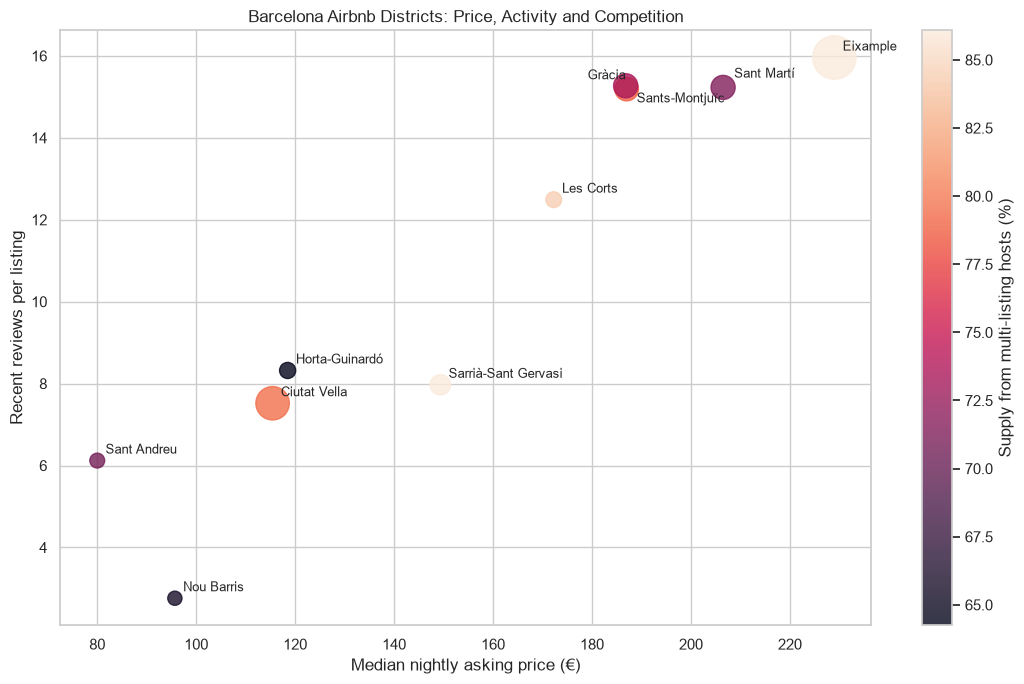

In [37]:
fig, ax = plt.subplots(figsize=(11, 7))

bubble_sizes = q7_result["listings"] / q7_result["listings"].max() * 900 + 80

scatter = ax.scatter(
    q7_result["median_nightly_price"],
    q7_result["recent_reviews_per_listing"],
    s=bubble_sizes,
    c=q7_result["pct_listings_from_multi_listing_hosts"],
    alpha=0.8
)

label_offsets = {
    "Eixample": (6, 5),
    "Sant Martí": (8, 7),
    "Sants-Montjuïc": (8, -12),
    "Gràcia": (-28, 7),
    "Les Corts": (6, 5),
    "Sarrià-Sant Gervasi": (6, 5),
    "Horta-Guinardó": (6, 5),
    "Ciutat Vella": (6, 5),
    "Sant Andreu": (6, 5),
    "Nou Barris": (6, 5)
}

for _, row in q7_result.iterrows():
    ax.annotate(
        row["district_name"],
        (row["median_nightly_price"], row["recent_reviews_per_listing"]),
        xytext=label_offsets[row["district_name"]],
        textcoords="offset points",
        fontsize=9
    )

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Supply from multi-listing hosts (%)")

ax.set_title("Barcelona Airbnb Districts: Price, Activity and Competition")
ax.set_xlabel("Median nightly asking price (€)")
ax.set_ylabel("Recent reviews per listing")

plt.tight_layout()
plt.show()

**Takeaway:** Eixample sits at the strongest end of both pricing and recent review activity, but it also has very high multi-listing host concentration. Sant Martí is close on activity and price while showing a lower concentration of multi-listing supply, making the trade-off between opportunity and competition particularly visible.

### 4.2 Like-for-like nightly prices

The overall price comparison could be affected by different property mixes across districts. This chart therefore compares only entire homes or apartments accommodating two guests.

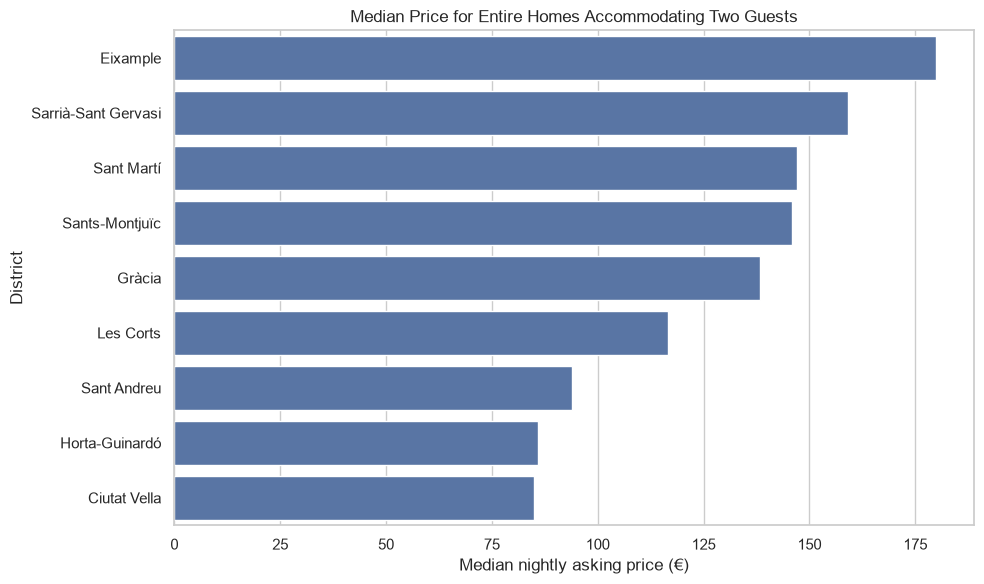

In [33]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=q2_entire_2,
    x="median_nightly_price",
    y="district_name"
)

plt.title("Median Price for Entire Homes Accommodating Two Guests")
plt.xlabel("Median nightly asking price (€)")
plt.ylabel("District")
plt.tight_layout()
plt.show()

**Takeaway:** Eixample remains the highest-priced district when the comparison is restricted to the same room type and guest capacity, suggesting that its higher overall price is not simply caused by a different property mix.

### 4.3 Multi-listing host concentration

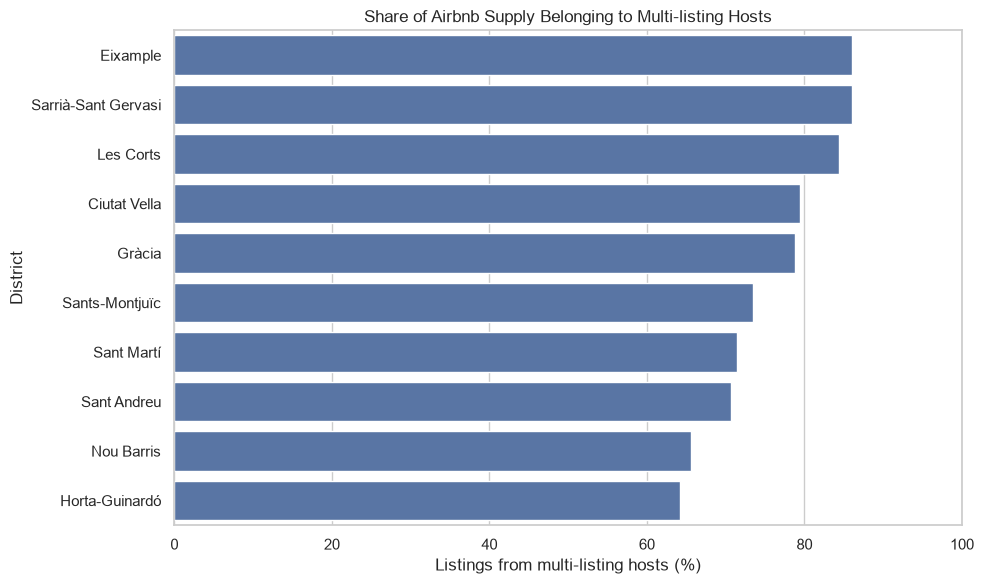

In [34]:
q5_plot = q5_result.sort_values(
    "pct_listings_from_multi_listing_hosts",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=q5_plot,
    x="pct_listings_from_multi_listing_hosts",
    y="district_name"
)

plt.title("Share of Airbnb Supply Belonging to Multi-listing Hosts")
plt.xlabel("Listings from multi-listing hosts (%)")
plt.ylabel("District")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

**Takeaway:** Multi-listing hosts control the majority of Airbnb supply in every Barcelona district. The concentration is particularly high in Eixample, Sarrià-Sant Gervasi and Les Corts, showing that attractive pricing can come with a more concentrated competitive landscape.

## 5. Conclusions

The analysis shows that there is no single measure that identifies the best Airbnb investment area. Pricing potential, evidence of guest activity and competition need to be considered together.

**Eixample** stands out most clearly on pricing and activity. It has the highest overall median nightly asking price at €229 and the highest recent review activity at 15.96 reviews per listing. It also remains the highest-priced district when similar two-person entire homes are compared. However, 86.08% of its Airbnb supply belongs to multi-listing hosts, suggesting a highly concentrated competitive market.

**Sant Martí** also shows a strong combination of price and activity. Its median nightly asking price is €206.50 and it records 15.23 recent reviews per listing, while its multi-listing host concentration is lower than Eixample at 71.45%.

**Sants-Montjuïc** and **Gràcia** also show strong recent guest activity at around 15 reviews per listing, although their median nightly prices are lower at approximately €187.

The analysis therefore suggests that **Eixample, Sant Martí, Sants-Montjuïc and Gràcia are the districts most worth investigating further**. They represent different trade-offs rather than one obvious winner.

For a potential investor, the next stage would be to investigate individual neighbourhoods and properties within these districts and combine the Airbnb market data with information about property purchase prices, operating costs, regulation and achievable occupancy before making an investment decision.

## 6. Limitations and next steps

This analysis can help narrow down areas for further investigation, but it cannot determine whether an Airbnb property would be a profitable investment on its own.

There are several important limitations:

- The listed nightly price is an asking price and does not show the price actually paid by guests.
- Reviews are used as a proxy for guest activity, but not every guest leaves a review, so they are not the same as confirmed bookings.
- The occupancy and revenue fields are modelled estimates rather than observed Airbnb booking or financial records.
- Some listings have missing price and estimated revenue data.
- The dataset represents one snapshot of the Barcelona Airbnb market, so market conditions may change over time.
- The analysis does not include property purchase prices, mortgage costs, maintenance, cleaning, taxes or other operating expenses.
- Local short-term rental regulation and licence availability are not included, even though they would be essential to a real investment decision.
- District-level results can hide important differences between individual neighbourhoods and properties.

A useful next step would therefore be to combine this analysis with property prices, regulatory information and more detailed neighbourhood-level analysis. This would allow potential return and risk to be assessed rather than relying only on Airbnb market activity.

In [35]:
conn.close()